In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams['figure.figsize'] = (8.5, 6.0)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10

In [2]:
root = Path('..').resolve()
figures_dir = root / 'paper' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(root / 'artifacts' / 'results_grid.csv')

agg = (
    df.groupby(['n_params', 'train_tokens_real'], as_index=False)
      .agg(
          val_loss=('val_loss', 'mean'),
          val_loss_std=('val_loss', 'std'),
          mu=('mu_landscape', 'mean'),
          mu_std=('mu_landscape', 'std'),
          flops=('flops_estimate', 'mean'),
          seeds=('seed', 'count'),
      )
)

agg['ratio'] = agg['train_tokens_real'] / agg['n_params']
agg['log_ratio'] = np.log10(agg['ratio'])
agg['logC'] = np.log10(agg['flops'])

print('raw rows:', len(df), 'agg points:', len(agg))
agg.head()

raw rows: 397 agg points: 201


,n_params,train_tokens_real,val_loss,val_loss_std,mu,mu_std,flops,seeds,ratio,log_ratio,logC
0,6540032,18432,10.921137,0.013132,0.003498,0.000077,7.232752e+11,2,0.002818,-2.550007,11.859304
1,6540032,38912,10.809240,0.029423,0.003493,0.000019,1.526914e+12,2,0.005950,-2.225496,12.183815
2,6540032,59392,10.638429,0.053112,0.003402,0.000015,2.330553e+12,2,0.009081,-2.041852,12.367459
3,6540032,79872,10.353947,0.088600,0.003190,0.000128,3.134193e+12,2,0.012213,-1.913185,12.496126
4,6540032,98304,10.011108,0.095843,0.002831,0.000059,3.857468e+12,2,0.015031,-1.823009,12.586302


isoFLOPs rows: 89


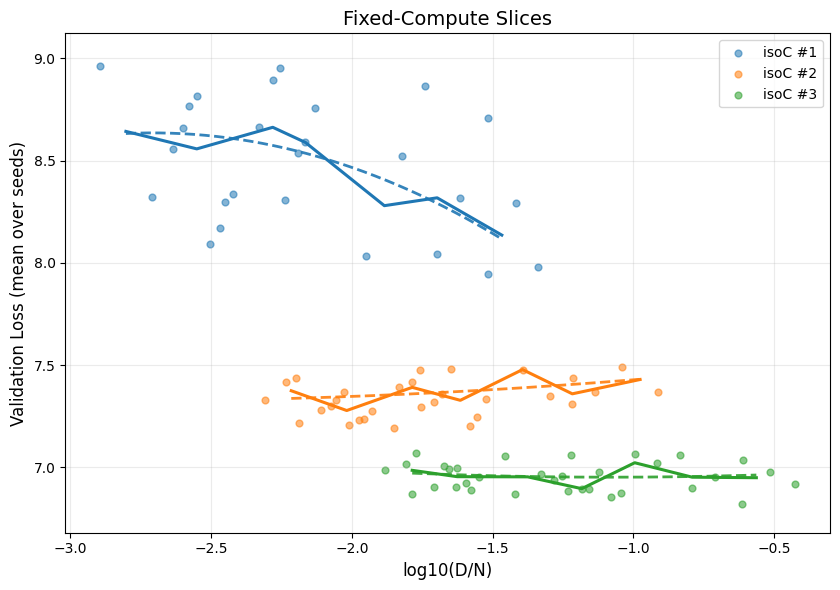

In [3]:
# Kaplan / Chinchilla style: val_loss vs log(D/N) inside isoFLOPs bands
# Use central quantiles and moderate width for stable, interpretable slices.
levels_count = 3
band_halfwidth = 0.14

c_levels = np.quantile(agg['logC'], np.linspace(0.25, 0.75, levels_count))
rows = []
for i, c0 in enumerate(c_levels, start=1):
    sub = agg[np.abs(agg['logC'] - c0) <= band_halfwidth].copy()
    if len(sub) < 6:
        continue
    sub['iso_id'] = i
    sub['logC_center'] = c0
    rows.append(sub)

iso = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
print('isoFLOPs rows:', len(iso))

fig, ax = plt.subplots(figsize=(8.5, 6.0))
if len(iso) == 0:
    print('No isoFLOPs bands found, increase band_halfwidth.')
else:
    cmap = plt.get_cmap('tab10')
    for iso_id, g in iso.groupby('iso_id'):
        g = g.sort_values('log_ratio')
        color = cmap((iso_id - 1) % 10)
        ax.scatter(g['log_ratio'], g['val_loss'], color=color, s=24, alpha=0.55, label=f'isoC #{iso_id}')
        if len(g) >= 8:
            bins = np.linspace(g['log_ratio'].min(), g['log_ratio'].max(), 8)
            g2 = g.copy()
            g2['bin'] = pd.cut(g2['log_ratio'], bins=bins, include_lowest=True)
            bmed = g2.groupby('bin', observed=False).agg(
                x=('log_ratio', 'median'),
                y=('val_loss', 'median'),
            ).dropna().sort_values('x')
            if len(bmed) >= 4:
                ax.plot(bmed['x'], bmed['y'], '-', color=color, linewidth=2.2)
                x, y = bmed['x'].values, bmed['y'].values
                coefs = np.polyfit(x, y, deg=2)
                xx = np.linspace(x.min(), x.max(), 200)
                yy = np.polyval(coefs, xx)
                ax.plot(xx, yy, '--', color=color, alpha=0.9, linewidth=2.0)

ax.set_xlabel('log10(D/N)')
ax.set_ylabel('Validation Loss (mean over seeds)')
ax.set_title('Fixed-Compute Slices')
if len(iso) > 0:
    ylo = np.nanpercentile(iso['val_loss'], 1)
    yhi = np.nanpercentile(iso['val_loss'], 99)
    pad = 0.08 * (yhi - ylo if yhi > ylo else 1.0)
    ax.set_ylim(ylo - pad, yhi + pad)
ax.legend(ncol=1, loc='upper right')
fig.tight_layout()
fig.savefig(figures_dir / 'exp03_kaplan_u_curves.png', dpi=240, bbox_inches='tight')
plt.show()

iso-mu rows: 306


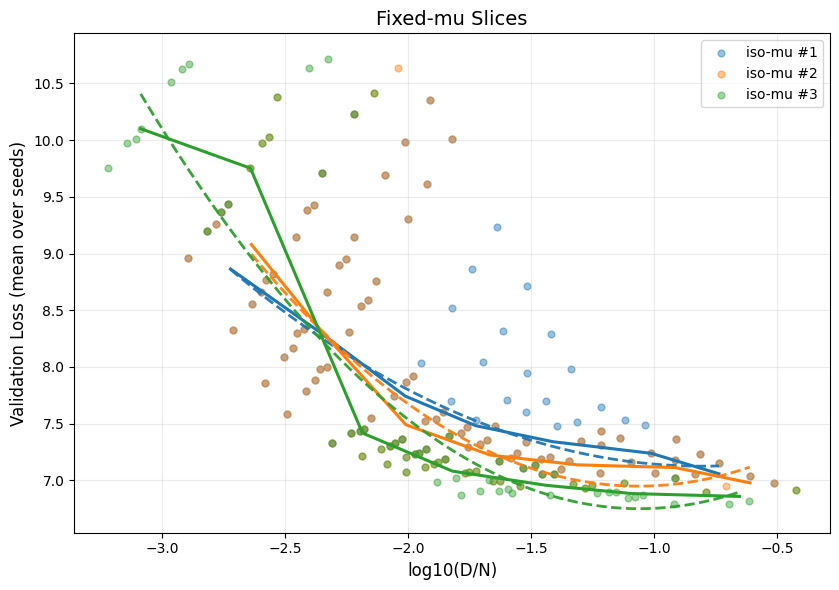

In [4]:
# iso-mu analog: val_loss vs log(D/N) inside fixed-mu bands
# Central quantiles and moderate width improve stability.
mu_levels_count = 3
mu_band_halfwidth = 0.0015

mu_levels = np.quantile(agg['mu'], np.linspace(0.25, 0.75, mu_levels_count))
rows_mu = []
for i, m0 in enumerate(mu_levels, start=1):
    sub = agg[np.abs(agg['mu'] - m0) <= mu_band_halfwidth].copy()
    if len(sub) < 6:
        continue
    # Trim extreme tails to reduce visually destabilizing outliers in main figure
    q_low, q_high = sub['val_loss'].quantile([0.05, 0.95])
    sub = sub[(sub['val_loss'] >= q_low) & (sub['val_loss'] <= q_high)].copy()
    if len(sub) < 5:
        continue
    sub['isomu_id'] = i
    sub['mu_center'] = m0
    rows_mu.append(sub)

isomu = pd.concat(rows_mu, ignore_index=True) if rows_mu else pd.DataFrame()
print('iso-mu rows:', len(isomu))

fig, ax = plt.subplots(figsize=(8.5, 6.0))
if len(isomu) == 0:
    print('No iso-mu bands found, increase mu_band_halfwidth.')
else:
    cmap = plt.get_cmap('tab10')
    for band_id, g in isomu.groupby('isomu_id'):
        g = g.sort_values('log_ratio')
        color = cmap((band_id - 1) % 10)
        ax.scatter(g['log_ratio'], g['val_loss'], color=color, s=24, alpha=0.45, label=f'iso-mu #{band_id}')
        if len(g) >= 8:
            # Robust trend: median-in-bins + quadratic fit on bin centers.
            bins = np.linspace(g['log_ratio'].min(), g['log_ratio'].max(), 8)
            g2 = g.copy()
            g2['bin'] = pd.cut(g2['log_ratio'], bins=bins, include_lowest=True)
            bmed = g2.groupby('bin', observed=False).agg(
                x=('log_ratio', 'median'),
                y=('val_loss', 'median'),
            ).dropna().sort_values('x')
            if len(bmed) >= 4:
                ax.plot(bmed['x'], bmed['y'], '-', color=color, linewidth=2.2)
                x, y = bmed['x'].values, bmed['y'].values
                coefs = np.polyfit(x, y, deg=2)
                xx = np.linspace(x.min(), x.max(), 200)
                yy = np.polyval(coefs, xx)
                ax.plot(xx, yy, '--', color=color, alpha=0.95, linewidth=2.0)

ax.set_xlabel('log10(D/N)')
ax.set_ylabel('Validation Loss (mean over seeds)')
ax.set_title('Fixed-mu Slices')
if len(isomu) > 0:
    ylo = np.nanpercentile(isomu['val_loss'], 1)
    yhi = np.nanpercentile(isomu['val_loss'], 99)
    pad = 0.08 * (yhi - ylo if yhi > ylo else 1.0)
    ax.set_ylim(ylo - pad, yhi + pad)
ax.legend(ncol=1, loc='upper right')
fig.tight_layout()
fig.savefig(figures_dir / 'exp03_isomu_slices.png', dpi=240, bbox_inches='tight')
plt.show()

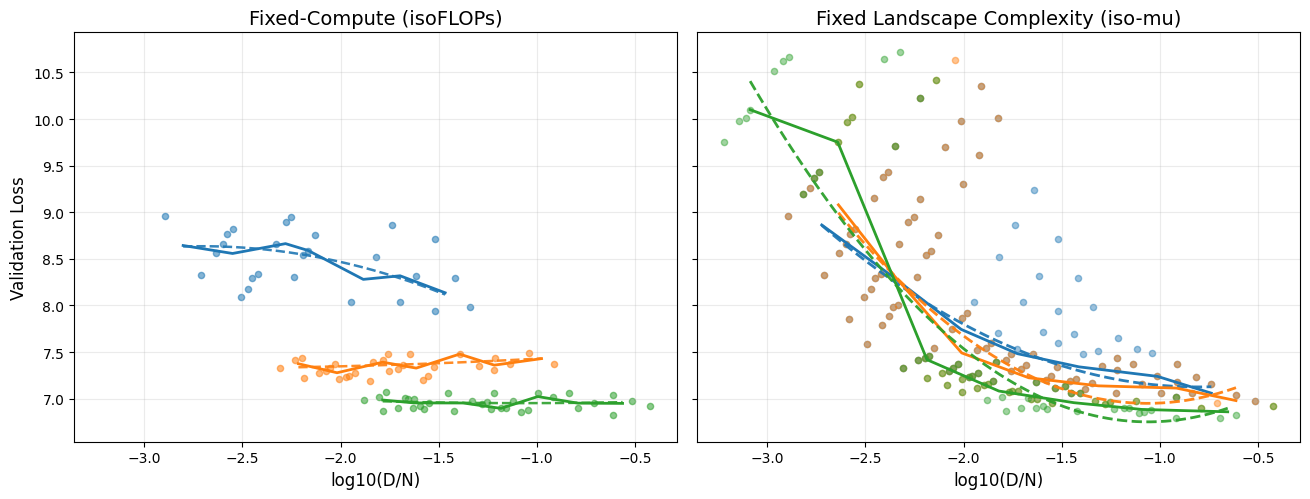

In [5]:
# Side-by-side comparison with identical axes (paper-ready)
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.1), sharex=True, sharey=True)

# left: isoFLOPs
if len(iso) > 0:
    cmap = plt.get_cmap('tab10')
    for iso_id, g in iso.groupby('iso_id'):
        g = g.sort_values('log_ratio')
        color = cmap((iso_id - 1) % 10)
        axes[0].scatter(g['log_ratio'], g['val_loss'], color=color, s=20, alpha=0.55)
        if len(g) >= 8:
            bins = np.linspace(g['log_ratio'].min(), g['log_ratio'].max(), 8)
            g2 = g.copy()
            g2['bin'] = pd.cut(g2['log_ratio'], bins=bins, include_lowest=True)
            bmed = g2.groupby('bin', observed=False).agg(
                x=('log_ratio', 'median'),
                y=('val_loss', 'median'),
            ).dropna().sort_values('x')
            if len(bmed) >= 4:
                axes[0].plot(bmed['x'], bmed['y'], '-', color=color, linewidth=2.0)
                x, y = bmed['x'].values, bmed['y'].values
                coefs = np.polyfit(x, y, deg=2)
                xx = np.linspace(x.min(), x.max(), 200)
                yy = np.polyval(coefs, xx)
                axes[0].plot(xx, yy, '--', color=color, alpha=0.9, linewidth=1.8)

axes[0].set_title('Fixed-Compute (isoFLOPs)')
axes[0].set_xlabel('log10(D/N)')
axes[0].set_ylabel('Validation Loss')
if len(iso) > 0 or len(isomu) > 0:
    y_parts = []
    if len(iso) > 0:
        y_parts.append(iso['val_loss'].values)
    if len(isomu) > 0:
        y_parts.append(isomu['val_loss'].values)
    y_all = np.concatenate(y_parts)
    ylo = np.nanpercentile(y_all, 1)
    yhi = np.nanpercentile(y_all, 99)
    pad = 0.08 * (yhi - ylo if yhi > ylo else 1.0)
    axes[0].set_ylim(ylo - pad, yhi + pad)

# right: iso-mu
if len(isomu) > 0:
    cmap = plt.get_cmap('tab10')
    for band_id, g in isomu.groupby('isomu_id'):
        g = g.sort_values('log_ratio')
        color = cmap((band_id - 1) % 10)
        axes[1].scatter(g['log_ratio'], g['val_loss'], color=color, s=20, alpha=0.45)
        if len(g) >= 8:
            bins = np.linspace(g['log_ratio'].min(), g['log_ratio'].max(), 8)
            g2 = g.copy()
            g2['bin'] = pd.cut(g2['log_ratio'], bins=bins, include_lowest=True)
            bmed = g2.groupby('bin', observed=False).agg(
                x=('log_ratio', 'median'),
                y=('val_loss', 'median'),
            ).dropna().sort_values('x')
            if len(bmed) >= 4:
                axes[1].plot(bmed['x'], bmed['y'], '-', color=color, linewidth=2.0)
                x, y = bmed['x'].values, bmed['y'].values
                coefs = np.polyfit(x, y, deg=2)
                xx = np.linspace(x.min(), x.max(), 200)
                yy = np.polyval(coefs, xx)
                axes[1].plot(xx, yy, '--', color=color, alpha=0.95, linewidth=2.0)

axes[1].set_title('Fixed Landscape Complexity (iso-mu)')
axes[1].set_xlabel('log10(D/N)')

for ax in axes:
    ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(figures_dir / 'exp03_compare_isoflops_vs_isomu.png', dpi=240, bbox_inches='tight')
plt.show()